In [1]:
import numpy as np
from typing import Any
from math import pi, sin, e
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
%matplotlib inline

In [2]:
def progonka(n: int, A: [float, ..., float], B: [float, ..., float], C: [float, ..., float], F: [float, ..., float], x1: float, x2: float, m1: float, m2: float) -> [float, ..., float]:
    a = [x1]
    b = [m1]
    y = []
    for i in range(n - 1):
        a.append(B[i] / (C[i] - A[i] * a[i]))
        b.append((F[i] + A[i] * b[i]) / (C[i] - A[i] * a[i]))
    y.append((m2 + x2 * b[n - 1]) / (1 - x2 * a[n - 1]))

    for i in reversed(range(n)):
        y.append(a[i] * y[n - 1 - i] + b[i])
    y.reverse()
    
    return y

In [3]:
def F(x = 0.0, t = 0.0):
    return 0
def mu1 (t = 0.0):
    return 0.0
def mu2 (t = 0.0):
    return 0.0
def fi(x = 0.0):
    return sin(pi * x)
def k(x = 0.0):
    return 1

def analyticalSolution(x: float, t: float):
    return e**(-(pi**2) * t) * sin(pi * x)


def yFunc(n: int, F: Any, k: Any, fi: Any, mu1: Any, mu2: Any, sigma: float, h: float, delta_tau: float, t_period: float) -> list[list, ..., list]:
    t = int(t_period / delta_tau + 1)
    cost = sigma * delta_tau / (h * h)
    y = [[0 for i in range(n + 1)] for i in range(t)]
    y[0][0] = mu1(0)
    y[0][n] = mu2(0)
    a = []
    b = []
    c = []
    f = []

    for i in range(n - 1):
        a.append(cost * k(i + 0.5))
        b.append(cost * k(i + 1.5))
        c.append(a[i] + b[i] + 1.0)
        y[0][i + 1] = fi(h * (i + 1))

    for i in range(1, t):
        for l in range(n - 1):
            f.append(delta_tau * (sigma * F(h * (l + 1), delta_tau * i) + (1 - sigma) * F(h * (l + 1), delta_tau * (i - 1))) + delta_tau * (1 - sigma) / (h * h) * ((k(l + 1.5) * (y[i - 1][l + 2] - y[i - 1][l + 1]) - k(l + 0.5) * (y[i - 1][l + 1] - y[i - 1][l]))) + y[i - 1][l + 1])
        y[i] = progonka(n, a, b, c, f, 0.0, 0.0, mu1(i * delta_tau), mu2(i * delta_tau));
        f = []
    return y

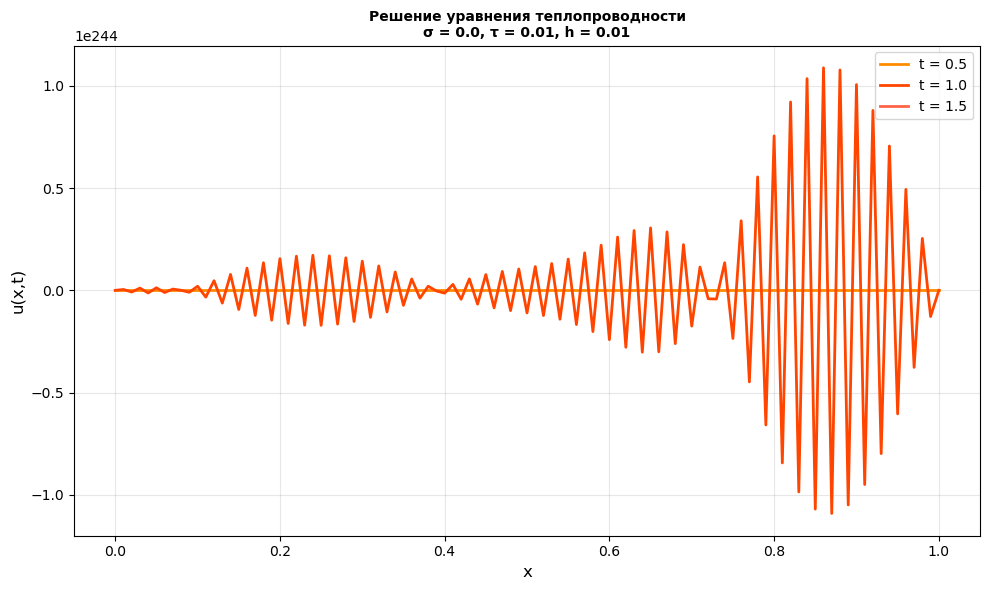

Максимальная ошибка =  2.6535898906415215e+306


In [4]:
sigma = 0.0
h = 0.01
delta_tau = 0.01
t_period = 3
max_error = 0
n = 100
t = int(t_period / delta_tau + 1)
y = yFunc(n, F, k, fi, mu1, mu2, sigma, h, delta_tau, t_period)
for i in range(t):
    for l in range(n + 1):
        if (abs(y[i][l] - analyticalSolution(h * l, i * delta_tau)) > max_error):
            max_error = abs(y[i][l] - analyticalSolution(h * l, i * delta_tau))
x = list(map(lambda i: i/100, list(range(0, 101))))

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot()
ax.plot(x, y[50], color='#FF8C00', linewidth=2, label='t = 0.5')
ax.plot(x, y[100], color='#FF4500', linewidth=2, label='t = 1.0')
ax.plot(x, y[150], color='#FF6347', linewidth=2, label='t = 1.5')
ax.grid(True, alpha=0.3)
plt.title(f'Решение уравнения теплопроводности\nσ = {sigma}, τ = {delta_tau}, h = {h}', fontsize=10, fontweight='bold')
ax.set_ylabel('u(x,t)', fontsize=12)
ax.set_xlabel('x', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Максимальная ошибка = ", max_error)

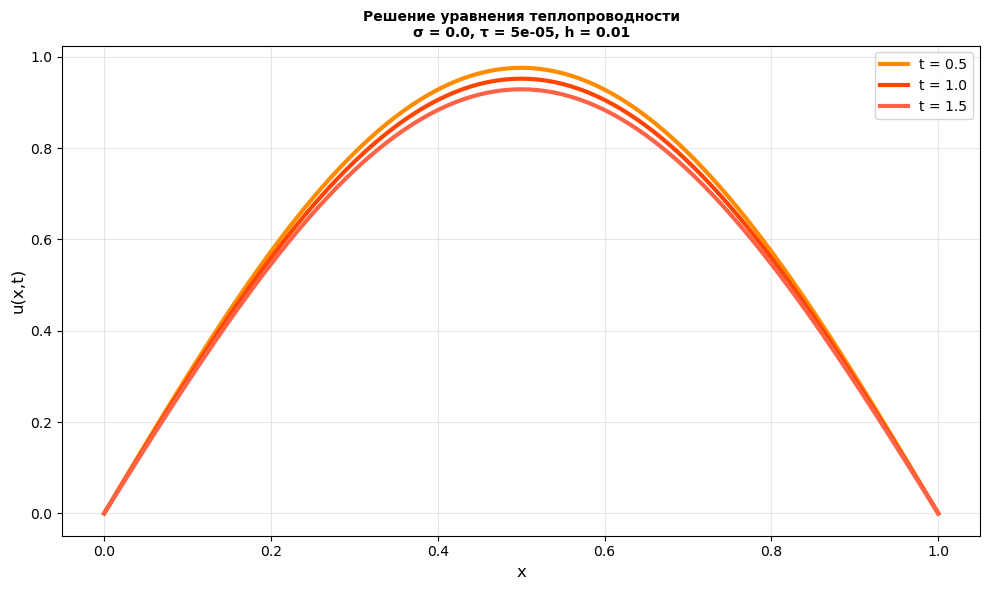

Максимальная ошибка =  6.052469419359774e-05


In [5]:
sigma = 0.0
h = 0.01
delta_tau = 0.00005
t_period = 3
max_error = 0
n = 100
t = int(t_period / delta_tau + 1)
y = yFunc(n, F, k, fi, mu1, mu2, sigma, h, delta_tau, t_period)
for i in range(t):
    for l in range(n + 1):
        if (abs(y[i][l] - analyticalSolution(h * l, i * delta_tau)) > max_error):
            max_error = abs(y[i][l] - analyticalSolution(h * l, i * delta_tau))
x = list(map(lambda i: i/100, list(range(0, 101))))

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot()

ax.plot(x, y[50], color='#FF8C00', linewidth=3, label='t = 0.5')
ax.plot(x, y[100], color='#FF4500', linewidth=3, label='t = 1.0')
ax.plot(x, y[150], color='#FF6347', linewidth=3, label='t = 1.5')
ax.grid(True, alpha=0.3)
plt.title(f'Решение уравнения теплопроводности\nσ = {sigma}, τ = {delta_tau}, h = {h}', fontsize=10, fontweight='bold')
ax.set_ylabel('u(x,t)', fontsize=12)
ax.set_xlabel('x', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Максимальная ошибка = ", max_error)

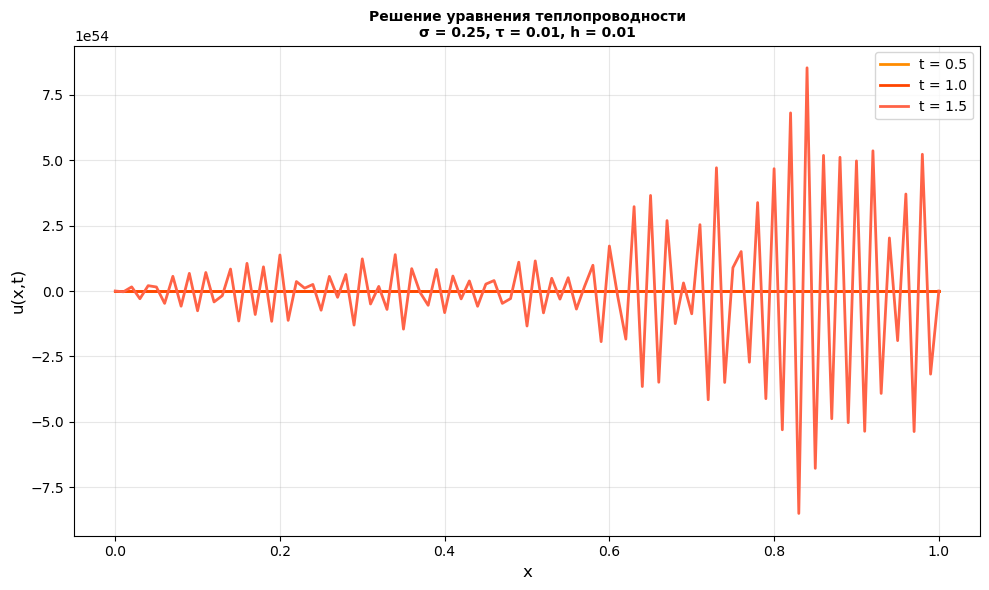

Максимальная ошибка =  3.885040293344344e+125


In [6]:
sigma = 0.25
h = 0.01
delta_tau = 0.01
t_period = 3
max_error = 0
n = 100

t = int(t_period / delta_tau + 1)
y = yFunc(n, F, k, fi, mu1, mu2, sigma, h, delta_tau, t_period)
for i in range(t):
    for l in range(n + 1):
        if (abs(y[i][l] - analyticalSolution(h * l, i * delta_tau)) > max_error):
            max_error = abs(y[i][l] - analyticalSolution(h * l, i * delta_tau))
x = list(map(lambda i: i/100, list(range(0, 101))))

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot()

ax.plot(x, y[50], color='#FF8C00', linewidth=2, label='t = 0.5')
ax.plot(x, y[100], color='#FF4500', linewidth=2, label='t = 1.0')
ax.plot(x, y[150], color='#FF6347', linewidth=2, label='t = 1.5')
ax.grid(True, alpha=0.3)
plt.title(f'Решение уравнения теплопроводности\nσ = {sigma}, τ = {delta_tau}, h = {h}', fontsize=10, fontweight='bold')
ax.set_ylabel('u(x,t)', fontsize=12)
ax.set_xlabel('x', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Максимальная ошибка = ", max_error)

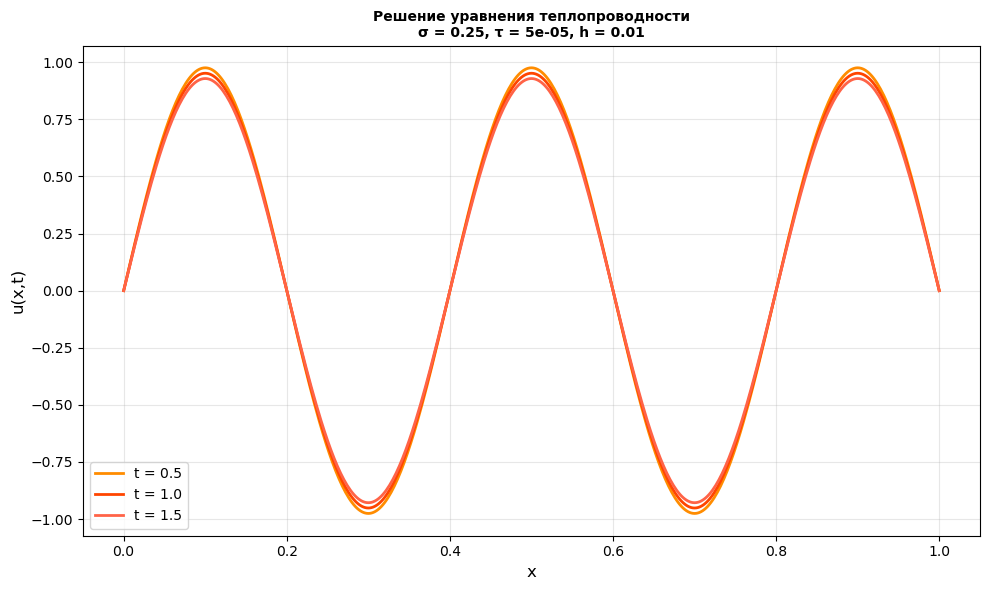

Максимальная ошибка =  1.513471935876698e-05


In [7]:
sigma = 0.25
h = 0.01
delta_tau = 0.00005
t_period = 3
max_error = 0
n = 500

t = int(t_period / delta_tau + 1)
y = yFunc(n, F, k, fi, mu1, mu2, sigma, h, delta_tau, t_period)
for i in range(t):
    for l in range(n + 1):
        if (abs(y[i][l] - analyticalSolution(h * l, i * delta_tau)) > max_error):
            max_error = abs(y[i][l] - analyticalSolution(h * l, i * delta_tau))
x = list(map(lambda i: i/500, list(range(0, 501))))

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot()

ax.plot(x, y[50], color='#FF8C00', linewidth=2, label='t = 0.5')
ax.plot(x, y[100], color='#FF4500', linewidth=2, label='t = 1.0')
ax.plot(x, y[150], color='#FF6347', linewidth=2, label='t = 1.5')
ax.grid(True, alpha=0.3)
plt.title(f'Решение уравнения теплопроводности\nσ = {sigma}, τ = {delta_tau}, h = {h}', fontsize=10, fontweight='bold')
ax.set_ylabel('u(x,t)', fontsize=12)
ax.set_xlabel('x', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Максимальная ошибка = ", max_error)

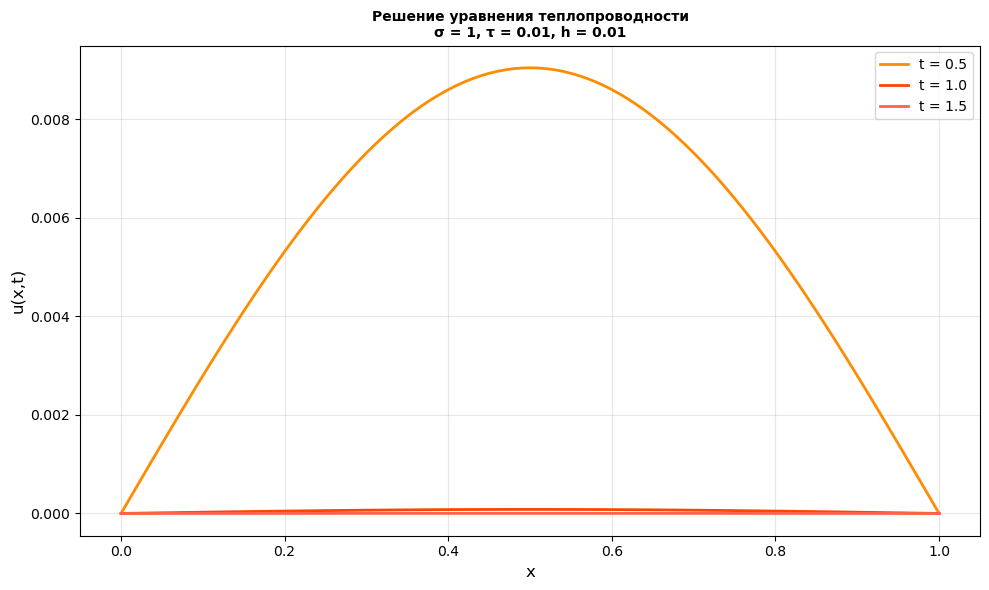

Максимальная ошибка =  0.01746450080623796


In [8]:
sigma = 1
h = 0.01
delta_tau = 0.01
t_period = 3
max_error = 0
n = 100

t = int(t_period / delta_tau + 1)
y = yFunc(n, F, k, fi, mu1, mu2, sigma, h, delta_tau, t_period)
for i in range(t):
    for l in range(n + 1):
        if (abs(y[i][l] - analyticalSolution(h * l, i * delta_tau)) > max_error):
            max_error = abs(y[i][l] - analyticalSolution(h * l, i * delta_tau))
x = list(map(lambda i: i/100, list(range(0, 101))))

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot()

ax.plot(x, y[50], color='#FF8C00', linewidth=2, label='t = 0.5')
ax.plot(x, y[100], color='#FF4500', linewidth=2, label='t = 1.0')
ax.plot(x, y[150], color='#FF6347', linewidth=2, label='t = 1.5')
ax.grid(True, alpha=0.3)
plt.title(f'Решение уравнения теплопроводности\nσ = {sigma}, τ = {delta_tau}, h = {h}', fontsize=10, fontweight='bold')
ax.set_ylabel('u(x,t)', fontsize=12)
ax.set_xlabel('x', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Максимальная ошибка = ", max_error)

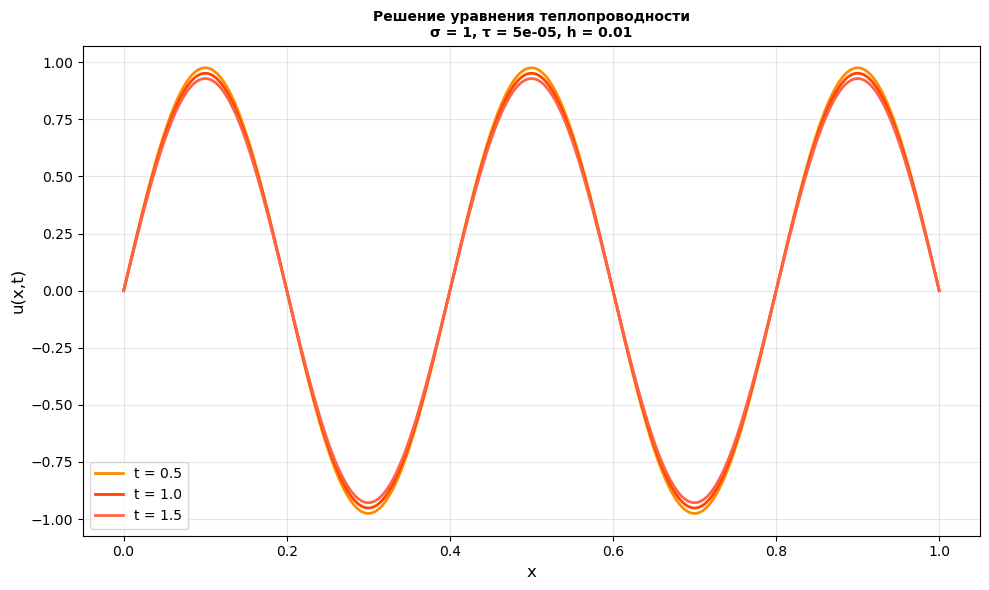

Максимальная ошибка =  0.00012100161180872426


In [9]:
sigma = 1
h = 0.01
delta_tau = 0.00005
t_period = 3
max_error = 0
n = 500

t = int(t_period / delta_tau + 1)
y = yFunc(n, F, k, fi, mu1, mu2, sigma, h, delta_tau, t_period)
for i in range(t):
    for l in range(n + 1):
        if (abs(y[i][l] - analyticalSolution(h * l, i * delta_tau)) > max_error):
            max_error = abs(y[i][l] - analyticalSolution(h * l, i * delta_tau))
x = list(map(lambda i: i/500, list(range(0, 501))))

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot()

ax.plot(x, y[50], color='#FF8C00', linewidth=2, label='t = 0.5')
ax.plot(x, y[100], color='#FF4500', linewidth=2, label='t = 1.0')
ax.plot(x, y[150], color='#FF6347', linewidth=2, label='t = 1.5')
ax.grid(True, alpha=0.3)
plt.title(f'Решение уравнения теплопроводности\nσ = {sigma}, τ = {delta_tau}, h = {h}', fontsize=10, fontweight='bold')
ax.set_ylabel('u(x,t)', fontsize=12)
ax.set_xlabel('x', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Максимальная ошибка = ", max_error)